# Cargamos los datos

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

historico_sensor_3 = "../data/silver/Sensor_temperatura/temperatura_media_por_hora.csv"
historico_sensor_5 = "../data/silver/Sensor_calefaccion/temperatura_calefaccion_historico.csv"

ruta_salida_prediccion = "../data/silver/Sensor_calefaccion/prediccion_temperatura_aula_calefaccion.csv"
ruta_salida_target = "../data/silver/Sensor_calefaccion/target_calefaccion.csv"

df_temp_aula = pd.read_csv(historico_sensor_3)
df_temp_ca = pd.read_csv(historico_sensor_5)

# Transformamos y limpiamos los datos

In [2]:
df_temp_aula['dia'] = pd.to_datetime(df_temp_aula['dia'], format='ISO8601').dt.date
df_temp_ca['dia'] = pd.to_datetime(df_temp_ca['date'], format='ISO8601').dt.date

df_temp_ca['hora'] = pd.to_datetime(df_temp_ca['time'], format='%H:%M').dt.hour
df_temp_ca['temp_aula_calefaccion'] = pd.to_numeric(df_temp_ca['temperature ℃'], errors='coerce')

df_entrenamiento = pd.merge(df_temp_aula, df_temp_ca, on=['dia', 'hora'], how='inner')

df_entrenamiento = df_entrenamiento.dropna(subset=['temp_media', 'temp_aula_calefaccion'])

# Generamos X e Y, Entrenamos el modelo

In [3]:
X = df_entrenamiento[['temp_media']]
y = df_entrenamiento['temp_aula_calefaccion']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Predecimos con X_test

In [4]:
prediccion_test = modelo.predict(X_test).round(1)

mae = mean_absolute_error(y_test, prediccion_test)
rmse = root_mean_squared_error(y_test, prediccion_test)
r2 = r2_score(y_test, prediccion_test)

print(f"Metricas del Modelo:")
print(f"MAE: {mae:.2f} °C")
print(f"RMSE: {rmse:.2f} °C")
print(f"Coeficiente de Determinacion (R2): {r2:.2f}")

Metricas del Modelo:
MAE: 0.54 °C
RMSE: 0.75 °C
Coeficiente de Determinacion (R2): 0.93


MAE: En promedio, las predicciones fallan por medio grado. 0. 54 °C

r2: El 93% de la variabilidad de la temperatura es explicada por la temperatura del aula

# Predecimos con la temperatura interior del aula y generamos el Target

In [5]:
df_temp_aula['temp_predicha'] = modelo.predict(df_temp_aula[['temp_media']]).round(1)

df_temp_aula['dia_semana_num'] = pd.to_datetime(df_temp_aula['dia']).dt.dayofweek

def decide_calefaccion(row):
    if row['dia_semana_num'] < 5: 
        return 1 if row['temp_predicha'] < 22.0 else 0
    return 0

df_temp_aula['target'] = df_temp_aula.apply(decide_calefaccion, axis=1)

df_target_final = df_temp_aula[['dia', 'hora', 'temp_predicha', 'target']]
df_target_final.to_csv(ruta_salida_target, index=False)

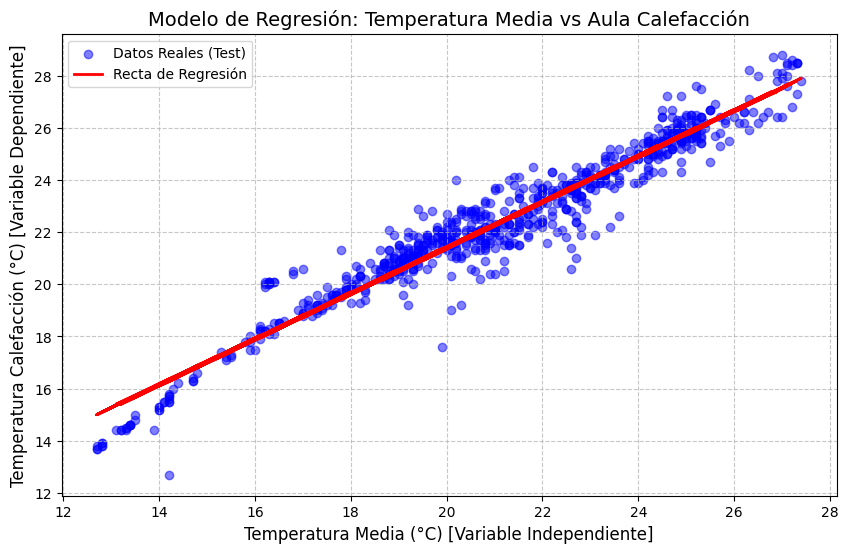

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Datos Reales (Test)')

plt.plot(X_test, prediccion_test, color='red', linewidth=2, label='Recta de Regresión')

plt.title('Modelo de Regresión: Temperatura Media vs Aula Calefacción', fontsize=14)
plt.xlabel('Temperatura Media (°C)', fontsize=12)
plt.ylabel('Temperatura Calefacción (°C)', fontsize=12)

plt.legend()

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()